# SVM bonus: Multi-class MNIST with One-vs-All

This notebook trains **10 binary SVMs** (one per digit) and combines them using the **one-vs-all** strategy:
- Train classifier *k* on labels `+1` for digit *k*, `-1` for all others.
- At test time, compute the decision **score** for each classifier and predict the digit with the largest score.

The dataset file is expected next to this notebook:
- `mnist_trn_multiclass_bonus.npz`


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from svm import svm, get_kernel

np.random.seed(0)


## Load MNIST data

In [2]:
data = np.load("mnist_trn_multiclass_bonus.npz", allow_pickle=True)

# robust field access
X = data["X"]
y = data["y"].astype(int).ravel()

if "imsize" in data:
    imsize = data["imsize"]
    # normalize possible formats
    if np.isscalar(imsize):
        im_h = int(imsize)
        im_w = int(imsize)
    else:
        imsize = np.array(imsize).ravel()
        if imsize.size == 1:
            im_h = im_w = int(imsize[0])
        else:
            im_h, im_w = int(imsize[0]), int(imsize[1])
else:
    im_h = im_w = 28

# ensure X is (d, N)
if X.ndim == 2:
    pass
elif X.ndim == 3:
    # sometimes images stored as HxWxN, flatten
    H, W, N = X.shape
    X = X.reshape(H*W, N)
    im_h, im_w = H, W
else:
    raise ValueError(f"Unexpected X shape: {X.shape}")

d, N = X.shape
print("X shape:", X.shape, "y shape:", y.shape, "image:", (im_h, im_w))
print("class counts:", {c:int((y==c).sum()) for c in range(10)})


X shape: (784, 30000) y shape: (30000,) image: (28, 28)
class counts: {0: 2961, 1: 3423, 2: 2948, 3: 3073, 4: 2926, 5: 2709, 6: 2975, 7: 3107, 8: 2875, 9: 3003}


## Stratified subsampling

To keep the run time and memory reasonable, we take the same number of samples per class for training and testing.
Adjust `train_per_class` / `test_per_class` if you want a larger/smaller run.


In [7]:
def stratified_split_indices(y, train_per_class=200, test_per_class=50, seed=0):
    rng = np.random.default_rng(seed)
    trn_idx = []
    tst_idx = []
    for c in range(10):
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        if idx.size < train_per_class + test_per_class:
            raise ValueError(f"Not enough samples for class {c}: have {idx.size}")
        trn_idx.append(idx[:train_per_class])
        tst_idx.append(idx[train_per_class:train_per_class + test_per_class])
    trn_idx = np.concatenate(trn_idx)
    tst_idx = np.concatenate(tst_idx)
    rng.shuffle(trn_idx)
    rng.shuffle(tst_idx)
    return trn_idx, tst_idx

train_per_class = 500   # 2000 total
test_per_class  = 50    # 500 total

itrn, itst = stratified_split_indices(y, train_per_class, test_per_class, seed=42)
X_trn, y_trn = X[:, itrn], y[itrn]
X_tst, y_tst = X[:, itst], y[itst]

print("Train:", X_trn.shape, "Test:", X_tst.shape)


Train: (784, 5000) Test: (784, 500)


## One-vs-all training (10 binary SVMs)

We use a **linear kernel** (fast and sensible for 784D pixel features).
`C` is the soft-margin parameter.


In [8]:
C = 2.0
options = {
    "kernel": "linear",
    "verb": False,
    "t_max": float("inf"),
}

models = []
for k in range(10):
    y_bin = np.where(y_trn == k, 1, -1).astype(float)
    print(f"Training SVM for digit {k} ...")
    model_k = svm(X_trn, y_bin, C, options)
    models.append(model_k)

print("Done.")


Training SVM for digit 0 ...
Training SVM for digit 1 ...
Training SVM for digit 2 ...
Training SVM for digit 3 ...
Training SVM for digit 4 ...
Training SVM for digit 5 ...
Training SVM for digit 6 ...
Training SVM for digit 7 ...
Training SVM for digit 8 ...
Training SVM for digit 9 ...
Done.


## Predict using decision scores

For each class `k`, score is:

$$
s_k(x) = \sum_i \alpha_i y_i \, k(x, x_i) + b
$$

We then predict `argmax_k s_k(x)`.


In [10]:
def decision_scores(X, model):
    sv = model["sv"]
    y_sv = np.asarray(model["y"]).ravel()
    alpha = np.asarray(model["alpha"]).ravel()
    b = float(model["b"])
    options = model.get("options", {"kernel": "linear"})

    K = get_kernel(sv, X, options)       # (m_sv, N)
    return (alpha * y_sv) @ K + b        # (N,)

# scores: (10, N_test)
S = np.vstack([decision_scores(X_tst, m) for m in models])
y_pred = np.argmax(S, axis=0)

acc = np.mean(y_pred == y_tst)
print(f"Test accuracy: {acc*100:.2f}%")

# confusion matrix
cm = np.zeros((10, 10), dtype=int)
for yt, yp in zip(y_tst, y_pred):
    cm[yt, yp] += 1

print("Confusion matrix (rows=true, cols=pred):")
print(cm)


Test accuracy: 83.00%
Confusion matrix (rows=true, cols=pred):
[[44  0  2  1  0  1  2  0  0  0]
 [ 0 45  0  0  0  1  0  0  4  0]
 [ 0  0 40  1  0  3  2  1  2  1]
 [ 1  0  1 43  0  3  0  1  1  0]
 [ 1  0  1  0 44  0  0  0  0  4]
 [ 1  1  0  5  2 37  0  1  3  0]
 [ 2  0  1  1  0  0 44  0  2  0]
 [ 0  1  0  0  2  0  0 42  0  5]
 [ 1  2  1  1  0  3  0  0 39  3]
 [ 0  1  1  3  3  0  0  4  1 37]]


## Montage of predictions

We show a small grid for each predicted class (first `n_show` images assigned to that class).


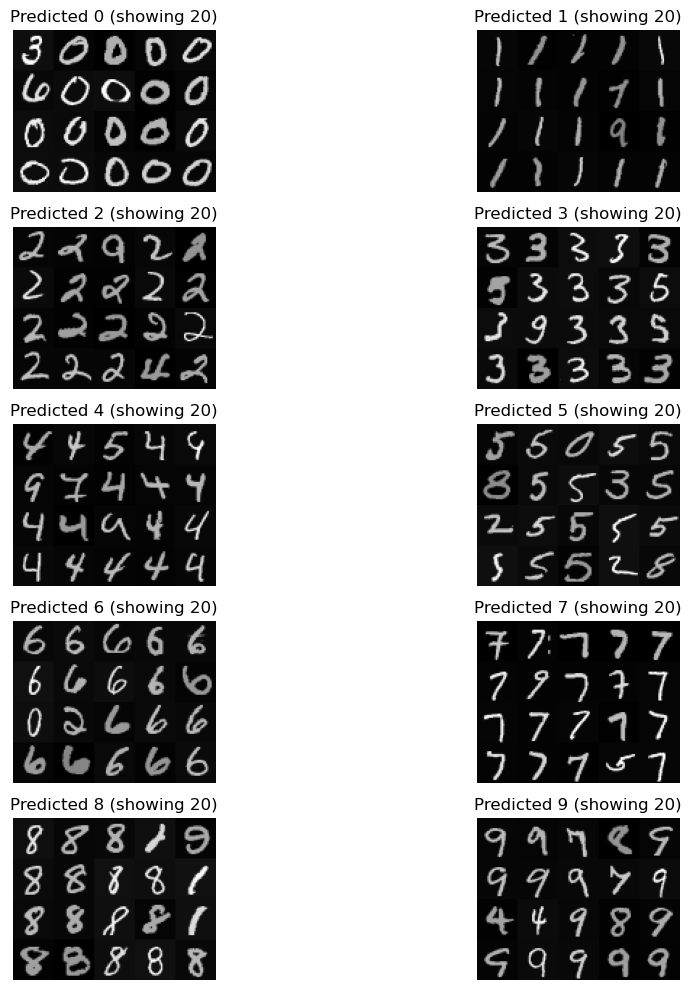

In [11]:
def show_montage_by_pred(X, y_pred, im_h, im_w, n_show=20):
    X = np.asarray(X)
    plt.figure(figsize=(12, 10))
    for digit in range(10):
        idx = np.flatnonzero(y_pred == digit)[:n_show]
        rows, cols = 4, 5  # for n_show=20
        canvas = np.ones((rows*im_h, cols*im_w)) * 0.1

        for j, ii in enumerate(idx):
            r = j // cols
            c = j % cols
            img = X[:, ii].reshape(im_h, im_w)
            canvas[r*im_h:(r+1)*im_h, c*im_w:(c+1)*im_w] = img

        ax = plt.subplot(5, 2, digit+1)
        ax.imshow(canvas, cmap="gray")
        ax.set_title(f"Predicted {digit} (showing {idx.size})")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_montage_by_pred(X_tst, y_pred, im_h, im_w, n_show=20)


## Notes

- If it’s slow or not enough memory, reduce `train_per_class`.
- For better accuracy, increase `train_per_class` and/or tune `C`.
- Optimization (?): RBF kernel, but it will be much heavier because it builds an `N x N` kernel matrix.
